# TextGraphicalizer: first WordNet ontology pass

Run the Laya-backed `TextGraphicalizer` on made-up paragraphs using the checked-in high-level WordNet ontology. The estimator owns the parameterized graph display function, so rendering can be reused outside this notebook.

> The first model load downloads the pinned Laya checkpoint into the Hugging Face cache.

## One-time setup

Use the existing `py312` kernel backed by the project venv. From the repository root, run these commands once in a terminal:

```bash
source ~/.venvs/py312/bin/activate
python -m pip install -e ".[notebook]"
python -m ipykernel install --user --name py312 --display-name "py312"
```

In [1]:
from pathlib import Path
import sys

assert (3, 10) <= sys.version_info[:2] <= (3, 12), (
    f"Use a Python 3.10–3.12 kernel; current interpreter is {sys.version}"
)
print(f"Using Python: {sys.executable}")

import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "ontology.yaml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from textgraphicalizer import TextGraphicalizer

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 15, "font.size": 10})
ontology_path = ROOT / "ontology.yaml"
stopwords_path = ROOT / "stopwords.yaml"
ontology_path

Using Python: /Users/f.costa/.venvs/py312/bin/python


PosixPath('/Users/f.costa/Code/TextGraphicalizer/ontology.yaml')

In [2]:
extractor = TextGraphicalizer()

## Multi-step paragraphs

In [3]:
paragraphs = [
    #("Bridge inspection", "After engineers detected a crack in the aging bridge, the transport authority closed the route, redirected buses through the eastern district, and commissioned a reinforced replacement before winter storms."),
    ("Wildfire evacuation", "When a wildfire approached the national park, firefighters evacuated the campground, built a temporary barrier along the access road, and moved injured hikers to a regional clinic."),
    #("Irrigation project", "A prolonged drought damaged the wheat harvest, so the farming cooperative installed drip irrigation, stored grain in a new warehouse, and distributed emergency supplies to nearby villages."),
    #("River monitoring", "The university research team assembled a solar-powered sensor, tested it beside the river, and transmitted measurements to a city laboratory that monitored water quality."),
    #("Coastal restoration", "A coastal municipality approved a restoration project after repeated flooding eroded the dunes, relocated several homes, and planted native grasses to protect the harbor."),
]

In [28]:
extractor.ontology = ontology_path
extractor.stopwords_path = stopwords_path
extractor.node_threshold = 0.15
extractor.edge_threshold = 0.2
extractor.connected = True
extractor.max_node_degree = 3
extractor.use_milp = True

In [29]:

graphs = []
for title, paragraph in paragraphs:
    graph = extractor.transform(paragraph)
    graphs.append((title, paragraph, graph))
    print(f"{title}: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

Wildfire evacuation: 11 nodes, 16 edges


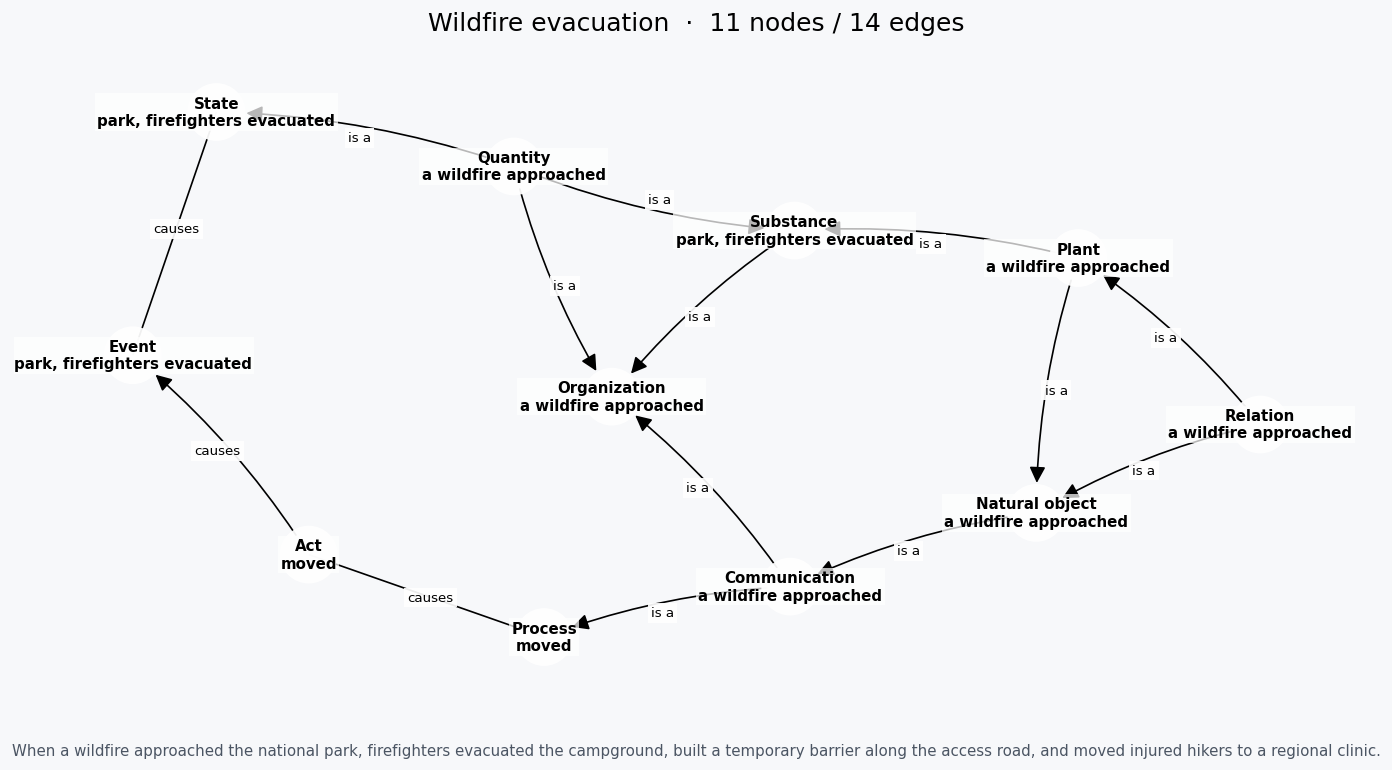

In [30]:
for title, paragraph, graph in graphs:
    extractor.display(graph, title=title, paragraph=paragraph)

## Inspect one graph as ordinary NetworkX data

In [31]:
title, paragraph, graph = graphs[2]
print("Nodes:")
display(list(graph.nodes(data=True)))
print("Edges:")
display(list(graph.edges(data=True)))
print("Graph metadata:")
display(graph.graph)

IndexError: list index out of range